# Explore latent space

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## corner plot

In [4]:
def make_corner(data_subset, title):
    grid = sns.PairGrid(data_subset, corner=True, diag_sharey=False)
    grid.map_lower(sns.scatterplot, s=1, alpha=0.1, color='teal')
    grid.map_diag(sns.kdeplot, fill=True, color='teal')
    grid.fig.suptitle(title, y=1.02)
    return grid

## Density colors

In [5]:
def get_density_colors(x, y, bins=100):
    """Calculates the density of points using a 2D histogram."""
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins)
    # Map each (x, y) point to the density value of its bin
    ix = np.clip(np.digitize(x, xedges) - 1, 0, bins - 1)
    iy = np.clip(np.digitize(y, yedges) - 1, 0, bins - 1)
    return hist[ix, iy]

# Config

## Directories

In [15]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


## Latent per bin

In [8]:
latent_bin_dict = {}

for bin_id in bins_ids:

    latent_bin_dict[bin_id] = np.load(
        f"{latent_dir}/{bin_id}/latent_{bin_id}.npy"
    )

# Corner plot

In [9]:
# bin_id = 'bin_03'

# latent_arr = latent_bin_dict[bin_id].copy()
# df_latent = pd.DataFrame(latent_arr, columns=[f'w_{i+1}' for i in range(12)])

# latent_scaled = standard_scaler(latent_arr)
# df_latent_scaled = pd.DataFrame(latent_scaled, columns=[f'w_{i+1}' for i in range(12)])


In [10]:
# def plot_dual_block(
#     data, group_a_idx, group_b_idx,
#     gridsize=100
# ):
#     # Both groups are size 6
#     n = 6 
#     fig, axes = plt.subplots(n, n, figsize=(14, 12))
    
#     for i in range(n):
#         for j in range(n):

#             ax = axes[i, j]
            
#             if i > j:
#                 # LOWER TRIANGLE: Group A (w1-w6)
#                 # i and j are local [0-5], map to group_a_idx
#                 v1 = group_a_idx[j]
#                 v2 = group_a_idx[i]
#                 ax.hexbin(
#                     data[:, v1], data[:, v2],
#                     gridsize=gridsize, cmap='viridis',
#                     mincnt=1
#                 )
                
#                 # Labels for Group A
#                 if i == n - 1: ax.set_xlabel(f"w_{v1+1}", fontweight='bold')
#                 if j == 0: ax.set_ylabel(f"w_{v2+1}", fontweight='bold')
                
#             elif i < j:
#                 # UPPER TRIANGLE: Group B (w7-w12)
#                 # Map local indices to group_b_idx
#                 v1, v2 = group_b_idx[j], group_b_idx[i]
#                 ax.hexbin(
#                     data[:, v1], data[:, v2],
#                     gridsize=gridsize,
#                     cmap='viridis',
#                     mincnt=1
#                 )
                
#                 # Labels for Group B (Top and Right)
#                 if i == 0: 
#                     ax.xaxis.set_label_position('top')
#                     ax.set_xlabel(f"w_{v1+1}", fontweight='bold')
#                 if j == n - 1: 
#                     ax.yaxis.set_label_position('right')
#                     ax.set_ylabel(f"w_{v2+1}", fontweight='bold')
                
#             else:
#                 # DIAGONAL: Variable Identifier
#                 # ax.text(0.5, 0.5, f"w_{group_a_idx[i]+1}\nvs\nw_{group_b_idx[i]+1}", 
#                         # ha='center', va='center', fontsize=10, fontweight='bold')
#                 ax.set_xticks([]); ax.set_yticks([])
            

#     return fig, axes

# # Execute
# idx_A = list(range(6))
# idx_B = list(range(6, 12))
# fig_dual = plot_dual_block(latent_scaled, idx_A, idx_B)
# plt.show()

In [11]:
# def plot_cross_group(data, group_a_idx, group_b_idx, gridsize=100):
#     # Both groups have 6 variables
#     n_a = len(group_a_idx)
#     n_b = len(group_b_idx)
    
#     fig, axes = plt.subplots(n_b, n_a, figsize=(15, 14))
    
#     for i, b_idx in enumerate(group_b_idx):
#         for j, a_idx in enumerate(group_a_idx):
#             ax = axes[i, j]
            
#             # Use hexbin to maintain consistency with your previous plots
#             hb = ax.hexbin(data[:, a_idx], data[:, b_idx], 
#                            gridsize=35, cmap='viridis', mincnt=1)
            
#             # # Set axis limits to maintain the same "zoom" level
#             # ax.set_xlim(-10, 5)
#             # ax.set_ylim(-5, 5)
            
#             # Labeling the outer axes only to prevent clutter
#             if i == n_b - 1:
#                 ax.set_xlabel(f"w_{a_idx+1}", fontweight='bold')
#             if j == 0:
#                 ax.set_ylabel(f"w_{b_idx+1}", fontweight='bold')
            
#             # Optional: cleaner ticks for internal plots
#             if i < n_b - 1: ax.set_xticklabels([])
#             if j > 0: ax.set_yticklabels([])


#     return fig, axes

# # Define your groups
# idx_A = list(range(6))
# idx_B = list(range(6, 12))

# # Generate the plot
# fig_cross = plot_cross_group(latent_scaled, idx_A, idx_B)
# plt.show()

In [12]:
# # Create a Pairplot for of latent dimensions
# # This helps check if the KLD/MMD worked: they should look roughly Gaussian
# sns.pairplot(df_latent_scaled, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10})
# plt.suptitle("Pairwise Projections of Latent Dimensions", y=1.02)
# plt.show()

# Umap

## bin_03

In [23]:
bin_id = 'bin_03'
latent_arr = latent_bin_dict[bin_id].copy()
latent_scaled = standard_scaler(latent_arr)
# ------------------------------------------------
print("UMAP representation")
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    # random_state=42
)
# Fit and Transform
embedding = reducer.fit_transform(latent_scaled)
save_to = f"{latent_dir}/{bin_id}/umap_latent_{bin_id}.npy"
np.save(save_to, embedding)
# -------------------------------------------------------------
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
print(f"UMAP embedding x: [{x_min:.2f}, {x_max:.2f}]")
print(f"UMAP embedding y: [{y_min:.2f}, {y_max:.2f}]")
# UMAP embedding x: [-3.44, 5.73]
# UMAP embedding y: [-1.59, 7.45]


UMAP representation
UMAP embedding x: [-3.67, 6.04]
UMAP embedding y: [-1.38, 7.33]


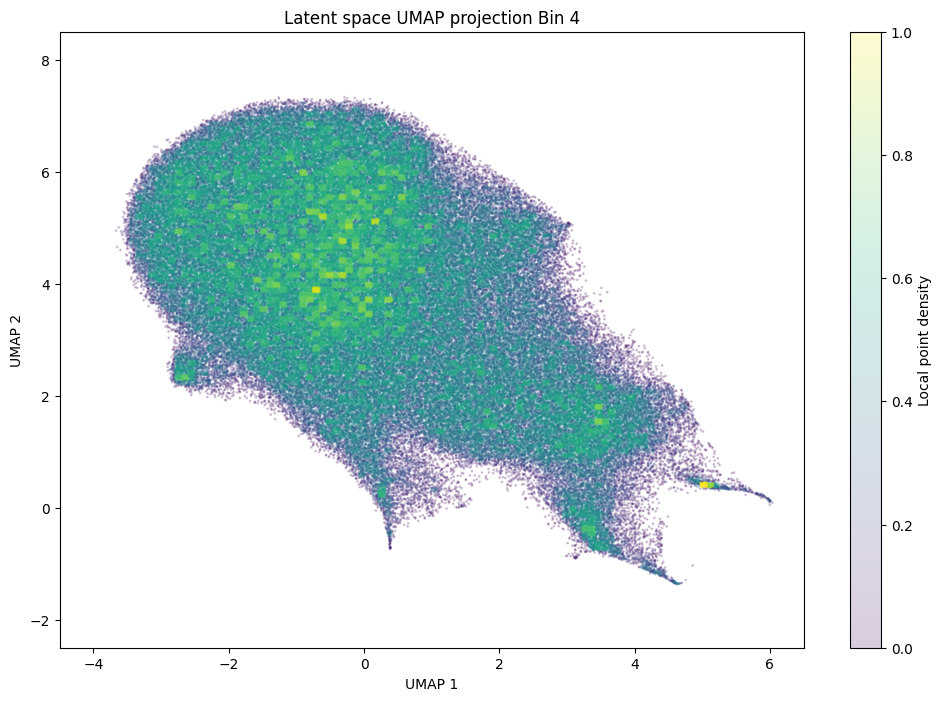

In [24]:
bin_number = int(bin_id.split('_')[1])
# 1. Calculate density based on your UMAP coordinates
density = get_density_colors(embedding[:, 0], embedding[:, 1], bins=100)
# 2. Sort points by density (optional: ensures densest points are drawn on top)
idx = density.argsort()
x_plot, y_plot, density_plot = embedding[idx, 0], embedding[idx, 1], density[idx]
norm_density = (density_plot - density_plot.min()) / (density_plot.max() - density_plot.min())
# ---------------------------------------------------------------------------------------------
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

scatter = ax.scatter(
    x_plot, y_plot, s=1, alpha=0.2,
    c=norm_density,
    cmap='viridis'
)
# -------------------------------------------------------------
x_ticks = [-4, -2, 0, 2, 4, 6]
ax.set_xticks(x_ticks)
x_limits = (-4.5, 6.5)
ax.set_xlim(x_limits)

y_ticks = [-2, 0, 2, 4, 6, 8]
ax.set_yticks(y_ticks)
y_limits = (-2.5, 8.5)
ax.set_ylim(y_limits)
# -------------------------------------------------------------

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f"Latent space UMAP projection Bin {bin_number + 1}")
fig.colorbar(scatter, ax=ax, label='Local point density')

# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/latent_space_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## bin_02

In [25]:
bin_id = 'bin_02'
latent_arr = latent_bin_dict[bin_id].copy()
latent_scaled = standard_scaler(latent_arr)
# ------------------------------------------------
print("UMAP representation")
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    # random_state=42
)
# Fit and Transform
embedding = reducer.fit_transform(latent_scaled)
save_to = f"{latent_dir}/{bin_id}/umap_latent_{bin_id}.npy"
np.save(save_to, embedding)
# -------------------------------------------------------------
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
print(f"UMAP embedding x: [{x_min:.2f}, {x_max:.2f}]")
print(f"UMAP embedding y: [{y_min:.2f}, {y_max:.2f}]")

UMAP representation
UMAP embedding x: [-4.28, 8.52]
UMAP embedding y: [4.39, 11.90]


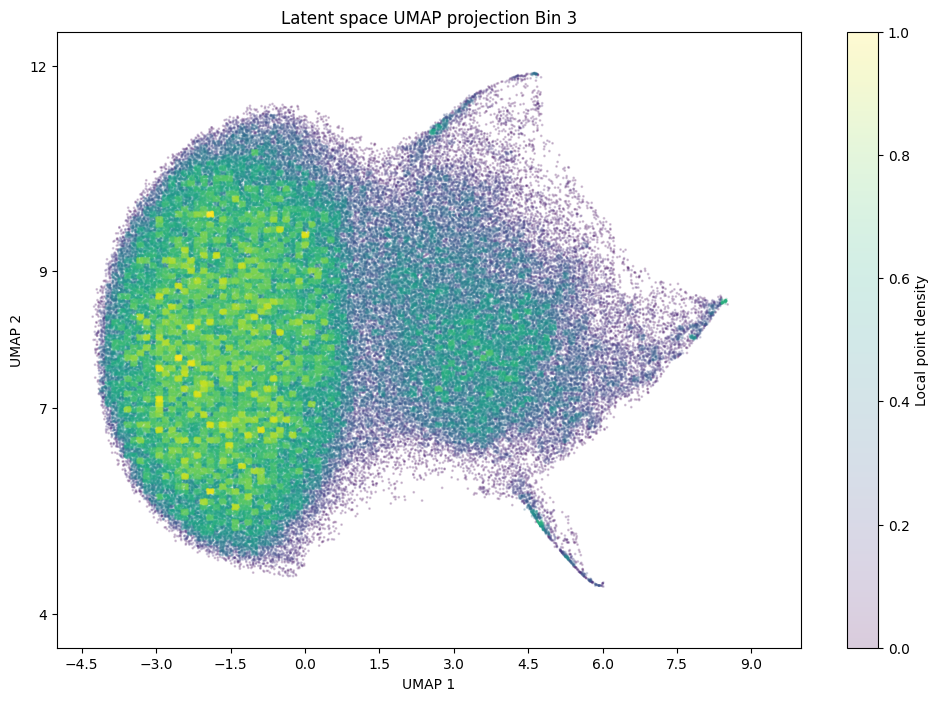

In [27]:
bin_number = int(bin_id.split('_')[1])
# 1. Calculate density based on your UMAP coordinates
density = get_density_colors(embedding[:, 0], embedding[:, 1], bins=100)
# 2. Sort points by density (optional: ensures densest points are drawn on top)
idx = density.argsort()
x_plot, y_plot, density_plot = embedding[idx, 0], embedding[idx, 1], density[idx]
norm_density = (density_plot - density_plot.min()) / (density_plot.max() - density_plot.min())
# ---------------------------------------------------------------------------------------------
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

scatter = ax.scatter(
    x_plot, y_plot, s=1, alpha=0.2,
    c=norm_density,
    cmap='viridis'
)
# -------------------------------------------------------------
x_ticks = [-4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6, 7.5, 9]
ax.set_xticks(x_ticks)
x_limits = (-5, 10)
ax.set_xlim(x_limits)

y_ticks = [4, 7, 9, 12]
ax.set_yticks(y_ticks)
y_limits = (3.5, 12.5)
ax.set_ylim(y_limits)
# -------------------------------------------------------------

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f"Latent space UMAP projection Bin {bin_number + 1}")
fig.colorbar(scatter, ax=ax, label='Local point density')

# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/latent_space_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## Bin 01

In [28]:
bin_id = 'bin_01'
latent_arr = latent_bin_dict[bin_id].copy()
latent_scaled = standard_scaler(latent_arr)
# ------------------------------------------------
print("UMAP representation")
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    # random_state=42
)
# Fit and Transform
embedding = reducer.fit_transform(latent_scaled)
save_to = f"{latent_dir}/{bin_id}/umap_latent_{bin_id}.npy"
np.save(save_to, embedding)
# -------------------------------------------------------------
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
print(f"UMAP embedding x: [{x_min:.2f}, {x_max:.2f}]")
print(f"UMAP embedding y: [{y_min:.2f}, {y_max:.2f}]")

UMAP representation
UMAP embedding x: [-3.27, 6.87]
UMAP embedding y: [5.02, 12.63]


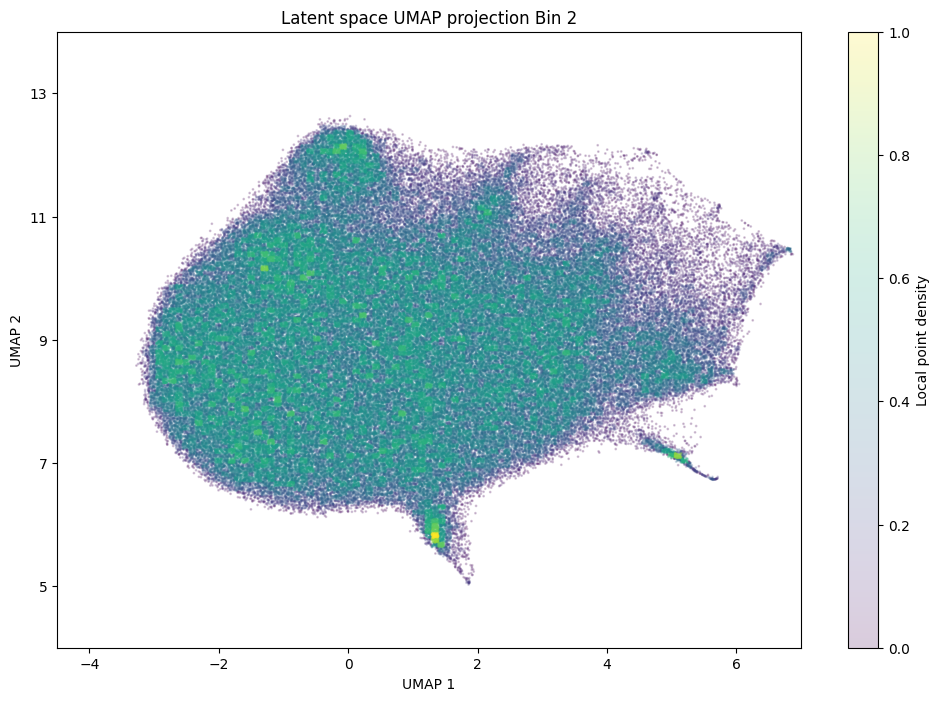

In [29]:
bin_number = int(bin_id.split('_')[1])
# 1. Calculate density based on your UMAP coordinates
density = get_density_colors(embedding[:, 0], embedding[:, 1], bins=100)
# 2. Sort points by density (optional: ensures densest points are drawn on top)
idx = density.argsort()
x_plot, y_plot, density_plot = embedding[idx, 0], embedding[idx, 1], density[idx]
norm_density = (density_plot - density_plot.min()) / (density_plot.max() - density_plot.min())
# ---------------------------------------------------------------------------------------------
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

scatter = ax.scatter(
    x_plot, y_plot, s=1, alpha=0.2,
    c=norm_density,
    cmap='viridis'
)
# -------------------------------------------------------------
x_ticks = [-4, -2, 0, 2, 4, 6]
ax.set_xticks(x_ticks)
x_limits = (-4.5, 7)
ax.set_xlim(x_limits)

y_ticks = [5, 7, 9, 11, 13]
ax.set_yticks(y_ticks)
y_limits = (4, 14)
ax.set_ylim(y_limits)
# -------------------------------------------------------------

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f"Latent space UMAP projection Bin {bin_number + 1}")
fig.colorbar(scatter, ax=ax, label='Local point density')

# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/latent_space_umap_{bin_id}.pdf",
    bbox_inches='tight'
)

## bin_00

In [30]:
bin_id = 'bin_00'
latent_arr = latent_bin_dict[bin_id].copy()
latent_scaled = standard_scaler(latent_arr)
# ------------------------------------------------
print("UMAP representation")
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    # random_state=42
)
# Fit and Transform
embedding = reducer.fit_transform(latent_scaled)
save_to = f"{latent_dir}/{bin_id}/umap_latent_{bin_id}.npy"
np.save(save_to, embedding)
# -------------------------------------------------------------
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
print(f"UMAP embedding x: [{x_min:.2f}, {x_max:.2f}]")
print(f"UMAP embedding y: [{y_min:.2f}, {y_max:.2f}]")

UMAP representation
UMAP embedding x: [-4.12, 6.11]
UMAP embedding y: [-2.80, 7.66]


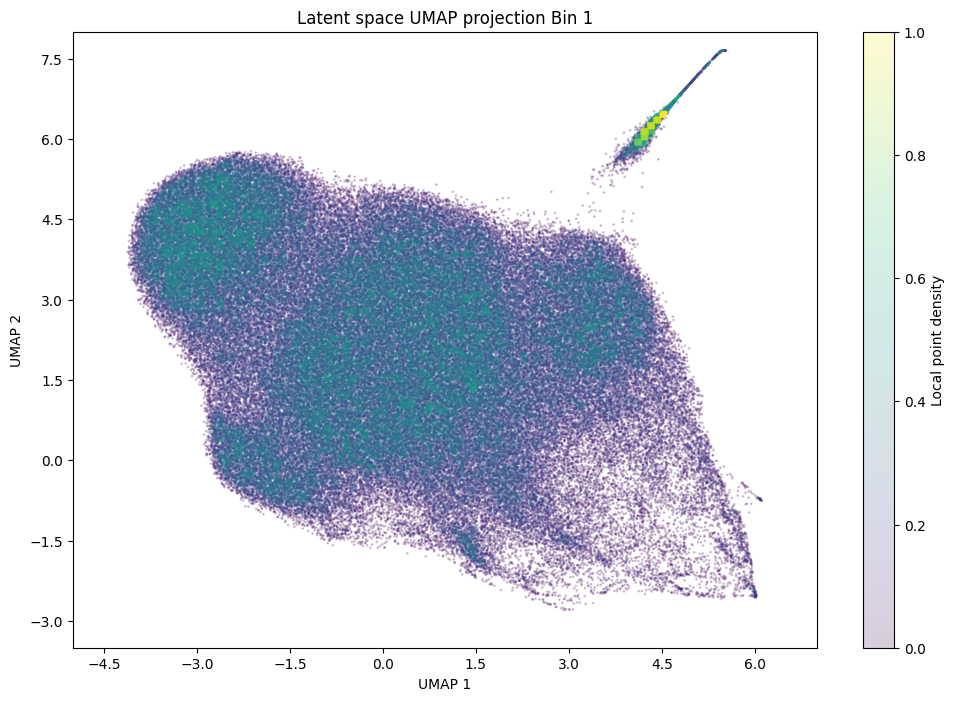

In [31]:
bin_number = int(bin_id.split('_')[1])
# 1. Calculate density based on your UMAP coordinates
density = get_density_colors(embedding[:, 0], embedding[:, 1], bins=100)
# 2. Sort points by density (optional: ensures densest points are drawn on top)
idx = density.argsort()
x_plot, y_plot, density_plot = embedding[idx, 0], embedding[idx, 1], density[idx]
norm_density = (density_plot - density_plot.min()) / (density_plot.max() - density_plot.min())
# ---------------------------------------------------------------------------------------------
fig, ax = plt.subplots(
    1, 1,
    figsize=(12, 8)
)

scatter = ax.scatter(
    x_plot, y_plot, s=1, alpha=0.2,
    c=norm_density,
    cmap='viridis'
)
# -------------------------------------------------------------
x_ticks = [-4.5, -3, -1.5, 0, 1.5, 3, 4.5, 6]
ax.set_xticks(x_ticks)
x_limits = (-5, 7)
ax.set_xlim(x_limits)

y_ticks = [-3, -1.5, 0, 1.5, 3, 4.5, 6, 7.5]
ax.set_yticks(y_ticks)
y_limits = (-3.5, 8)
ax.set_ylim(y_limits)
# -------------------------------------------------------------

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title(f"Latent space UMAP projection Bin {bin_number + 1}")
fig.colorbar(scatter, ax=ax, label='Local point density')

# save figure
fig.savefig(
    f"{ch4_dir}/{bin_id}/latent/latent_space_umap_{bin_id}.pdf",
    bbox_inches='tight'
)